# 11 Custom Model Visualization

This notebook visualizes the saved evaluation artifacts for the custom multimodal models. It supports both the earlier deep multimodal fusion variants and the stronger tabular multimodal XGBoost variants built from structured features plus BioClinicalBERT note embeddings.

## Visualization scope

- compare custom model variants within one selected family
- plot ROC curves from saved evaluation CSV artifacts
- plot precision-recall curves from saved evaluation CSV artifacts
- inspect calibration behavior and confusion matrices using stored thresholds
- compare validation versus test behavior for `xgboost_text_augmented` when raw split predictions are available
- save reusable figure files under `figures/11_custom_model_visualization/`

In [1]:
import sys
from pathlib import Path

NOTEBOOK_CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        candidate
        for candidate in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents]
        if (candidate / 'configs' / 'base.yaml').exists() and (candidate / 'src').is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate the project root from the current notebook directory.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.runtime import load_project_runtime

runtime = load_project_runtime(start=PROJECT_ROOT)
IN_COLAB = runtime.in_colab
PROJECT_ROOT = runtime.project_root
config = runtime.config
paths = runtime.paths

PROJECT_ROOT

PosixPath('/home/sra/shankari/Multimodal-Sepsis-Prediction-main-copy')

In [2]:
if IN_COLAB:
    %pip -q install pyyaml pandas numpy matplotlib scikit-learn

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix

from src.evaluation.artifacts import summarize_predictions
from src.evaluation.leakage import (
    compute_top_feature_label_correlations,
    find_suspicious_feature_names,
    prepare_structured_stay_table,
    run_shuffle_label_test,
    run_simple_model_sanity,
    summarize_patient_split_overlap,
    summarize_structured_time_leakage,
    summarize_text_keyword_hits,
    summarize_text_time_leakage,
)
from src.evaluation.visualization import (
    CUSTOM_MULTIMODAL_MODELS,
    plot_calibration_curves,
    plot_confusion_matrices,
    plot_metric_bars,
    plot_pr_curves,
    plot_roc_curves,
)
from src.utils.logging_utils import write_run_manifest

In [4]:
config['evaluation']

{'default_threshold': 0.5, 'calibration_bins': 10}

## Load saved evaluation artifacts

Notebook 08 already saved the curve tables and summary CSVs. This notebook reads those outputs directly rather than recomputing metrics.

In [5]:
evaluation_dir = paths['processed_data_dir'] / '08_evaluation'
baseline_prediction_dir = paths['processed_data_dir'] / '06_baseline_models'
multimodal_prediction_dir = paths['processed_data_dir'] / '07_multimodal_models'
figure_output_dir = paths['figures_dir'] / '11_custom_model_visualization'
figure_output_dir.mkdir(parents=True, exist_ok=True)

TABULAR_CUSTOM_MODELS = (
    'xgboost_text_augmented',
    'stacked_xgboost_notes',
)
MODEL_FAMILIES = {
    'tabular_xgboost': {
        'label': 'Tabular Multimodal XGBoost',
        'model_names': TABULAR_CUSTOM_MODELS,
        'prediction_dir': baseline_prediction_dir,
        'model_family_label': 'custom_tabular_multimodal',
    },
    'deep_fusion': {
        'label': 'Deep Multimodal Fusion',
        'model_names': CUSTOM_MULTIMODAL_MODELS,
        'prediction_dir': multimodal_prediction_dir,
        'model_family_label': 'custom_deep_multimodal',
    },
}

def _horizon_sort_key(dataset_name: str) -> tuple[int, str]:
    try:
        horizon_hours = int(str(dataset_name).replace('horizon_', '').replace('h', ''))
    except ValueError:
        horizon_hours = 10**9
    return horizon_hours, str(dataset_name)

def _summarize_family_predictions(prediction_dir: Path, model_names, model_family_label: str):
    rows = []
    curve_bundle = {}
    prediction_files = []
    source_stage = prediction_dir.name

    for model_name in model_names:
        for prediction_path in sorted(prediction_dir.glob(f'horizon_*_{model_name}_test_predictions.csv')):
            dataset_name = prediction_path.name.replace(f'_{model_name}_test_predictions.csv', '')
            predictions_df = pd.read_csv(prediction_path)
            metrics, curves = summarize_predictions(
                predictions_df=predictions_df,
                threshold=None,
                calibration_bins=config['evaluation']['calibration_bins'],
            )
            rows.append({
                'dataset_name': dataset_name,
                'model_name': model_name,
                'model_family': model_family_label,
                'source_stage': source_stage,
                'prediction_file': str(prediction_path),
                'split': 'test',
                **metrics,
            })
            curve_bundle[(dataset_name, model_name)] = {
                'prediction_path': str(prediction_path),
                'predictions_df': predictions_df,
                **curves,
            }
            prediction_files.append(str(prediction_path))

    evaluation_df = pd.DataFrame(rows)
    if not evaluation_df.empty:
        evaluation_df = evaluation_df.sort_values(
            ['dataset_name', 'model_name'],
            key=lambda column: column.map(_horizon_sort_key) if column.name == 'dataset_name' else column,
        ).reset_index(drop=True)
    return evaluation_df, curve_bundle, prediction_files

model_family = 'tabular_xgboost'
selected_family = MODEL_FAMILIES[model_family]
prediction_dir = selected_family['prediction_dir']

evaluation_summary_path = evaluation_dir / 'evaluation_summary.csv'
evaluation_df = pd.read_csv(evaluation_summary_path) if evaluation_summary_path.exists() else pd.DataFrame()

custom_eval_df, family_curve_bundle, family_prediction_files = _summarize_family_predictions(
    prediction_dir=prediction_dir,
    model_names=selected_family['model_names'],
    model_family_label=selected_family['model_family_label'],
)
assert not custom_eval_df.empty, f'No prediction files found for {selected_family["label"]} in {prediction_dir}.'

tabular_results_files = sorted(baseline_prediction_dir.glob('horizon_*_tabular_multimodal_results.csv'))
tabular_results_df = pd.concat([pd.read_csv(path) for path in tabular_results_files], ignore_index=True) if tabular_results_files else pd.DataFrame()

available_horizons = sorted(custom_eval_df['dataset_name'].unique().tolist(), key=_horizon_sort_key)
summary_columns = [column for column in ['dataset_name', 'model_family', 'model_name', 'source_stage', 'auroc', 'auprc', 'f1'] if column in custom_eval_df.columns]
model_family, selected_family['label'], available_horizons, custom_eval_df[summary_columns].reset_index(drop=True)


('tabular_xgboost',
 'Tabular Multimodal XGBoost',
 ['horizon_6h', 'horizon_12h', 'horizon_24h'],
   dataset_name               model_family              model_name  \
 0   horizon_6h  custom_tabular_multimodal   stacked_xgboost_notes   
 1   horizon_6h  custom_tabular_multimodal  xgboost_text_augmented   
 2  horizon_12h  custom_tabular_multimodal   stacked_xgboost_notes   
 3  horizon_12h  custom_tabular_multimodal  xgboost_text_augmented   
 4  horizon_24h  custom_tabular_multimodal   stacked_xgboost_notes   
 5  horizon_24h  custom_tabular_multimodal  xgboost_text_augmented   
 
          source_stage     auroc     auprc        f1  
 0  06_baseline_models  0.995750  0.964008  0.951456  
 1  06_baseline_models  0.999017  0.978884  0.954545  
 2  06_baseline_models  0.995224  0.948237  0.935743  
 3  06_baseline_models  0.998910  0.971010  0.939271  
 4  06_baseline_models  0.996619  0.929053  0.953168  
 5  06_baseline_models  0.999359  0.982061  0.958217  )

## Select the horizon to visualize

Change `dataset_name` below if you want to plot another horizon.

In [6]:
requested_horizon = globals().get('requested_horizon', 'horizon_6h')
dataset_name = requested_horizon if requested_horizon in available_horizons else available_horizons[0]
model_names = [
    model_name
    for model_name in selected_family['model_names']
    if ((custom_eval_df['dataset_name'] == dataset_name) & (custom_eval_df['model_name'] == model_name)).any()
]
overfit_model_name = 'xgboost_text_augmented' if 'xgboost_text_augmented' in model_names else (model_names[0] if model_names else None)

{
    'requested_horizon': requested_horizon,
    'selected_horizon': dataset_name,
    'available_horizons': available_horizons,
    'model_names': model_names,
    'overfit_model_name': overfit_model_name,
}


{'requested_horizon': 'horizon_6h',
 'selected_horizon': 'horizon_6h',
 'available_horizons': ['horizon_6h', 'horizon_12h', 'horizon_24h'],
 'model_names': ['xgboost_text_augmented', 'stacked_xgboost_notes'],
 'overfit_model_name': 'xgboost_text_augmented'}

## Cross-family custom-model comparison

This section compares three custom-model families on the selected horizon:

- `aligned_transformer_xgboost`
- `custom_model_transformer` = best deep multimodal fusion variant for the chosen horizon
- `custom_model_xgboost` = `xgboost_text_augmented`

The deep multimodal variant is chosen automatically by highest test AUPRC for the selected horizon.

In [7]:
aligned_prediction_dir = paths['processed_data_dir'] / config.get('aligned_transformer_xgboost', {}).get('output_stage', '10_aligned_transformer_xgboost')

combined_comparison_df = pd.DataFrame()
combined_curve_bundle = {}
combined_metric_fig = None
combined_roc_fig = None
combined_pr_fig = None
combined_calibration_fig = None
combined_confusion_fig = None

def _load_custom_model_bundle(alias_model_name: str, source_model_name: str, prediction_path: Path, legend_label: str):
    predictions_df = pd.read_csv(prediction_path)
    metrics, curves = summarize_predictions(
        predictions_df=predictions_df,
        threshold=None,
        calibration_bins=config['evaluation']['calibration_bins'],
    )
    row = {
        'dataset_name': dataset_name,
        'model_name': alias_model_name,
        'source_model_name': source_model_name,
        'legend_label': legend_label,
        'prediction_path': str(prediction_path),
        **metrics,
    }
    bundle = {
        'predictions_df': predictions_df,
        'metrics': metrics,
        'legend_label': legend_label,
        'source_model_name': source_model_name,
        'prediction_path': str(prediction_path),
        **curves,
    }
    return row, bundle

deep_candidates = []
for deep_model_name in CUSTOM_MULTIMODAL_MODELS:
    deep_path = multimodal_prediction_dir / f'{dataset_name}_{deep_model_name}_test_predictions.csv'
    if not deep_path.exists():
        continue
    deep_row, deep_bundle = _load_custom_model_bundle(
        alias_model_name='custom_model_transformer',
        source_model_name=deep_model_name,
        prediction_path=deep_path,
        legend_label=f'custom_model_transformer ({deep_model_name})',
    )
    deep_candidates.append((deep_row, deep_bundle))

assert deep_candidates, f'No deep multimodal test predictions found for {dataset_name}.'
best_deep_row, best_deep_bundle = sorted(
    deep_candidates,
    key=lambda item: (item[0]['auprc'], item[0]['auroc']),
    reverse=True,
)[0]

xgboost_path = baseline_prediction_dir / f'{dataset_name}_xgboost_text_augmented_test_predictions.csv'
aligned_path = aligned_prediction_dir / f'{dataset_name}_aligned_transformer_xgboost_test_predictions.csv'
assert xgboost_path.exists(), f'Missing custom XGBoost prediction file: {xgboost_path}'
assert aligned_path.exists(), f'Missing aligned Transformer + XGBoost prediction file: {aligned_path}'

xgboost_row, xgboost_bundle = _load_custom_model_bundle(
    alias_model_name='custom_model_xgboost',
    source_model_name='xgboost_text_augmented',
    prediction_path=xgboost_path,
    legend_label='custom_model_xgboost (xgboost_text_augmented)',
)
aligned_row, aligned_bundle = _load_custom_model_bundle(
    alias_model_name='aligned_transformer_xgboost',
    source_model_name='aligned_transformer_xgboost',
    prediction_path=aligned_path,
    legend_label='aligned_transformer_xgboost',
)

comparison_rows = [aligned_row, best_deep_row, xgboost_row]
combined_comparison_df = pd.DataFrame(comparison_rows)
comparison_order = ['aligned_transformer_xgboost', 'custom_model_transformer', 'custom_model_xgboost']
combined_comparison_df['plot_order'] = combined_comparison_df['model_name'].map({name: idx for idx, name in enumerate(comparison_order)})
combined_comparison_df = combined_comparison_df.sort_values('plot_order').reset_index(drop=True)

combined_curve_bundle = {
    'aligned_transformer_xgboost': aligned_bundle,
    'custom_model_transformer': best_deep_bundle,
    'custom_model_xgboost': xgboost_bundle,
}

combined_comparison_df[[
    'dataset_name',
    'model_name',
    'source_model_name',
    'auroc',
    'auprc',
    'accuracy',
    'precision',
    'recall',
    'f1',
    'decision_threshold',
]]


,dataset_name,model_name,source_model_name,auroc,auprc,accuracy,precision,recall,f1,decision_threshold
0,horizon_6h,aligned_transformer_xgboost,aligned_transformer_xgboost,0.998627,0.974953,0.995195,0.932907,0.976589,0.954248,0.250000
1,horizon_6h,custom_model_transformer,cross_modal_attention,0.796884,0.277121,0.920542,0.280749,0.351171,0.312036,0.008086
2,horizon_6h,custom_model_xgboost,xgboost_text_augmented,0.999017,0.978884,0.995195,0.927445,0.983278,0.954545,0.175563


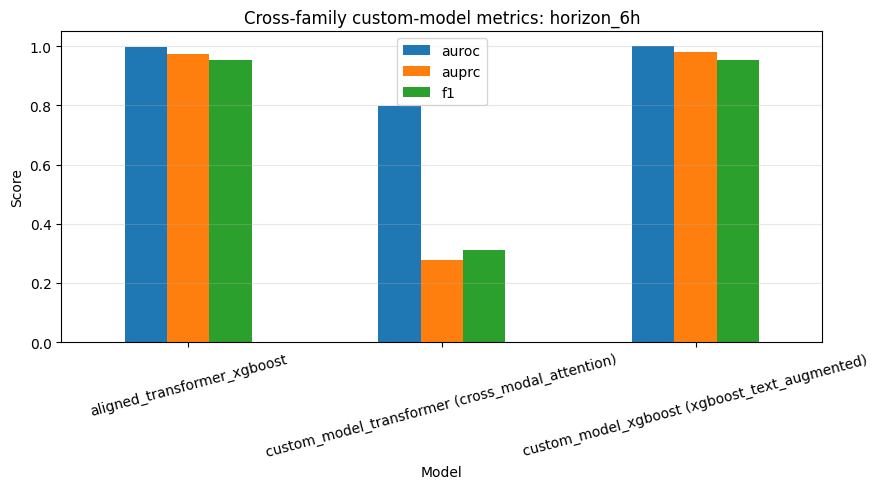

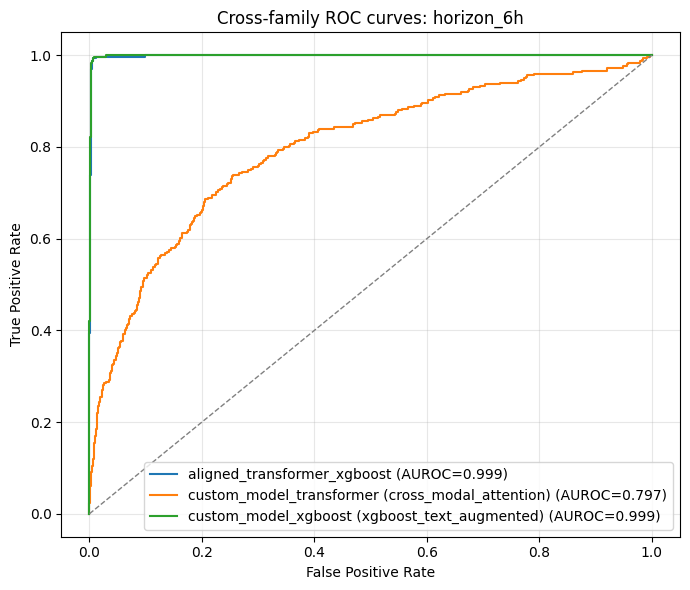

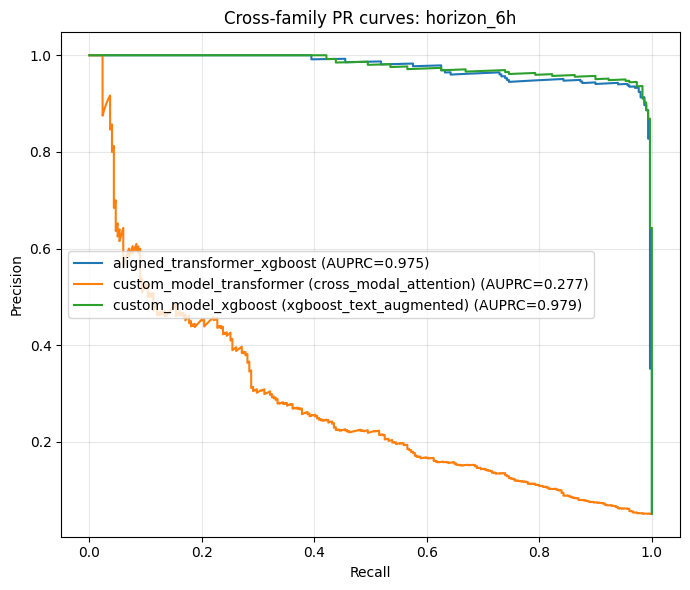

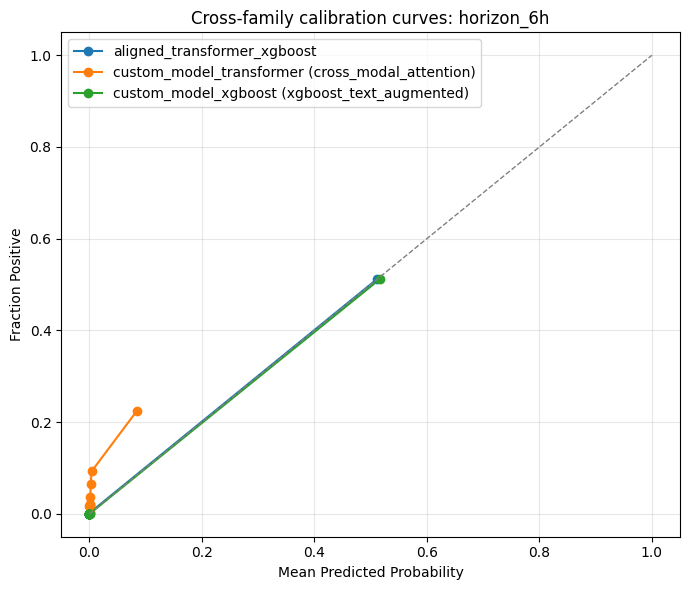

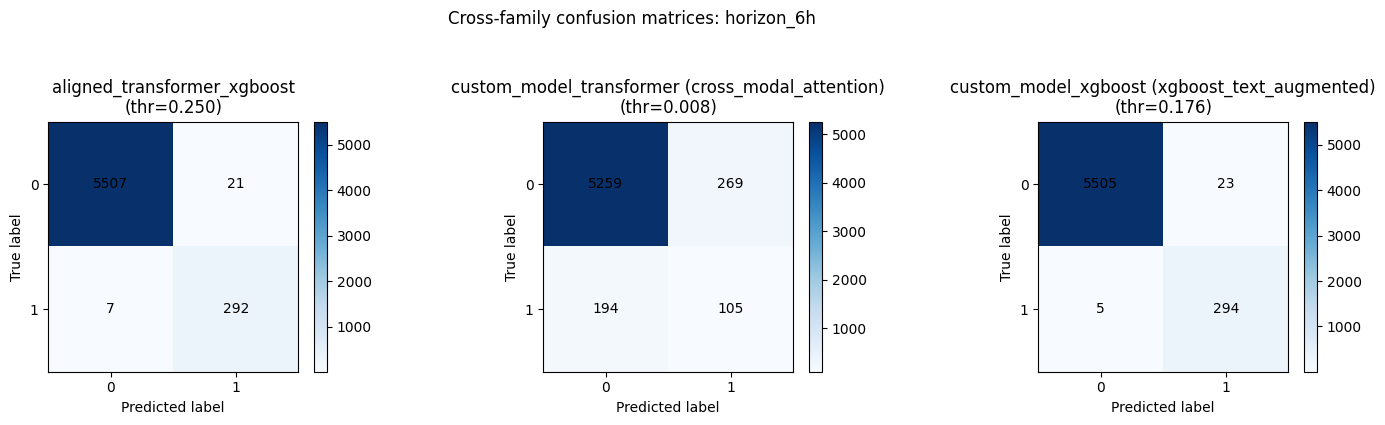

In [8]:
if not combined_comparison_df.empty:
    ordered_aliases = combined_comparison_df['model_name'].tolist()
    metric_table = combined_comparison_df.set_index('legend_label')[['auroc', 'auprc', 'f1']]
    combined_metric_fig, combined_metric_ax = plt.subplots(figsize=(9, 5))
    metric_table.plot(kind='bar', ax=combined_metric_ax, rot=15)
    combined_metric_ax.set_title(f'Cross-family custom-model metrics: {dataset_name}')
    combined_metric_ax.set_ylabel('Score')
    combined_metric_ax.set_xlabel('Model')
    combined_metric_ax.grid(True, axis='y', alpha=0.3)
    combined_metric_ax.set_ylim(0.0, 1.05)
    combined_metric_fig.tight_layout()
    plt.show()

    combined_roc_fig, combined_roc_ax = plt.subplots(figsize=(7, 6))
    for alias_name in ordered_aliases:
        bundle = combined_curve_bundle[alias_name]
        curve = bundle['roc_curve']
        combined_roc_ax.plot(curve['fpr'], curve['tpr'], label=f"{bundle['legend_label']} (AUROC={bundle['metrics']['auroc']:.3f})")
    combined_roc_ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
    combined_roc_ax.set_title(f'Cross-family ROC curves: {dataset_name}')
    combined_roc_ax.set_xlabel('False Positive Rate')
    combined_roc_ax.set_ylabel('True Positive Rate')
    combined_roc_ax.grid(True, alpha=0.3)
    combined_roc_ax.legend()
    combined_roc_fig.tight_layout()
    plt.show()

    combined_pr_fig, combined_pr_ax = plt.subplots(figsize=(7, 6))
    for alias_name in ordered_aliases:
        bundle = combined_curve_bundle[alias_name]
        curve = bundle['pr_curve']
        combined_pr_ax.plot(curve['recall'], curve['precision'], label=f"{bundle['legend_label']} (AUPRC={bundle['metrics']['auprc']:.3f})")
    combined_pr_ax.set_title(f'Cross-family PR curves: {dataset_name}')
    combined_pr_ax.set_xlabel('Recall')
    combined_pr_ax.set_ylabel('Precision')
    combined_pr_ax.grid(True, alpha=0.3)
    combined_pr_ax.legend()
    combined_pr_fig.tight_layout()
    plt.show()

    combined_calibration_fig, combined_calibration_ax = plt.subplots(figsize=(7, 6))
    for alias_name in ordered_aliases:
        bundle = combined_curve_bundle[alias_name]
        curve = bundle['calibration']
        combined_calibration_ax.plot(
            curve['mean_predicted_probability'],
            curve['fraction_positive'],
            marker='o',
            label=bundle['legend_label'],
        )
    combined_calibration_ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
    combined_calibration_ax.set_title(f'Cross-family calibration curves: {dataset_name}')
    combined_calibration_ax.set_xlabel('Mean Predicted Probability')
    combined_calibration_ax.set_ylabel('Fraction Positive')
    combined_calibration_ax.grid(True, alpha=0.3)
    combined_calibration_ax.legend()
    combined_calibration_fig.tight_layout()
    plt.show()

    combined_confusion_fig, combined_confusion_axes = plt.subplots(1, len(ordered_aliases), figsize=(5 * len(ordered_aliases), 4))
    if len(ordered_aliases) == 1:
        combined_confusion_axes = [combined_confusion_axes]
    for axis, alias_name in zip(combined_confusion_axes, ordered_aliases):
        bundle = combined_curve_bundle[alias_name]
        predictions_df = bundle['predictions_df']
        threshold_values = pd.to_numeric(predictions_df.get('decision_threshold', pd.Series(dtype=float)), errors='coerce').dropna()
        resolved_threshold = float(threshold_values.iloc[0]) if not threshold_values.empty else float(config['evaluation']['default_threshold'])
        y_true = predictions_df['y_true'].astype(int)
        y_pred = (predictions_df['y_prob'].astype(float) >= resolved_threshold).astype(int)
        matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
        image = axis.imshow(matrix, cmap='Blues')
        axis.set_title(f"{bundle['legend_label']}\n(thr={resolved_threshold:.3f})")
        axis.set_xlabel('Predicted label')
        axis.set_ylabel('True label')
        axis.set_xticks([0, 1])
        axis.set_yticks([0, 1])
        axis.set_xticklabels(['0', '1'])
        axis.set_yticklabels(['0', '1'])
        for row in range(matrix.shape[0]):
            for column in range(matrix.shape[1]):
                axis.text(column, row, str(matrix[row, column]), ha='center', va='center', color='black')
        combined_confusion_fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    combined_confusion_fig.suptitle(f'Cross-family confusion matrices: {dataset_name}', y=1.05)
    combined_confusion_fig.tight_layout()
    plt.show()
else:
    print('Cross-family comparison could not be built for the selected horizon.')


## Leakage audit for the tabular XGBoost custom model

This section checks the main leakage risks for the current horizon:

- patient overlap across `train`, `val`, and `test`
- structured rows after the prediction time or outside the history window
- positive examples where `prediction_time` is not strictly before `sepsis_onset_time`
- note windows with note timestamps after the prediction time
- suspicious feature names that directly reveal the label
- unusually high structured-feature correlations with the label
- a simple logistic-regression sanity model
- a shuffled-label test using XGBoost on the structured stay-level features

Note: the correlation and sanity-model checks use the structured stay-level tabular features. Text leakage is checked separately at the raw note-window level, because the BioClinicalBERT embedding dimensions are not directly interpretable.

In [9]:
structured_audit_df = pd.DataFrame()
text_audit_df = pd.DataFrame()
feature_manifest_df = pd.DataFrame()
structured_stay_table = pd.DataFrame()
leakage_paths = {}

if model_family == 'tabular_xgboost':
    structured_dataset_path = paths['processed_data_dir'] / '04_feature_engineering' / f'{dataset_name}.csv'
    text_dataset_path = paths['processed_data_dir'] / '05_text_processing' / f'{dataset_name}_note_windows.csv'
    feature_manifest_path = baseline_prediction_dir / f'{dataset_name}_tabular_multimodal_feature_manifest.csv'
    leakage_paths = {
        'structured_dataset_path': structured_dataset_path,
        'text_dataset_path': text_dataset_path,
        'feature_manifest_path': feature_manifest_path,
    }
    assert structured_dataset_path.exists(), f'Missing structured dataset: {structured_dataset_path}'
    assert text_dataset_path.exists(), f'Missing text dataset: {text_dataset_path}'
    structured_audit_df = pd.read_csv(
        structured_dataset_path,
        parse_dates=['hour', 'prediction_time', 'sepsis_onset_time', 'INTIME', 'OUTTIME'],
        low_memory=False,
    )
    text_audit_df = pd.read_csv(
        text_dataset_path,
        parse_dates=['prediction_time', 'first_note_time', 'last_note_time'],
        low_memory=False,
    )
    if feature_manifest_path.exists():
        feature_manifest_df = pd.read_csv(feature_manifest_path)
    structured_stay_table = prepare_structured_stay_table(structured_audit_df, config)

leakage_paths, structured_audit_df.shape, text_audit_df.shape, structured_stay_table.shape, feature_manifest_df.shape

({'structured_dataset_path': PosixPath('/home/sra/shankari/Multimodal-Sepsis-Prediction-main-copy/results/processed/04_feature_engineering/horizon_6h.csv'),
  'text_dataset_path': PosixPath('/home/sra/shankari/Multimodal-Sepsis-Prediction-main-copy/results/processed/05_text_processing/horizon_6h_note_windows.csv'),
  'feature_manifest_path': PosixPath('/home/sra/shankari/Multimodal-Sepsis-Prediction-main-copy/results/processed/06_baseline_models/horizon_6h_tabular_multimodal_feature_manifest.csv')},
 (1268294, 90),
 (114663, 12),
 (38447, 436),
 (1987, 2))

In [10]:
patient_overlap_df = pd.DataFrame()
structured_time_df = pd.DataFrame()
text_time_df = pd.DataFrame()
text_keyword_df = pd.DataFrame()
suspicious_feature_names_df = pd.DataFrame()
top_corr_df = pd.DataFrame()
suspicious_corr_df = pd.DataFrame()
simple_model_df = pd.DataFrame()
shuffle_df = pd.DataFrame()
val_test_gap_df = pd.DataFrame()
leakage_checklist_df = pd.DataFrame()

if model_family == 'tabular_xgboost' and not structured_audit_df.empty:
    patient_overlap_df = summarize_patient_split_overlap(structured_audit_df)
    structured_time_df = summarize_structured_time_leakage(
        structured_audit_df,
        history_window_hours=int(config['feature_engineering']['history_window_hours']),
    )
    text_time_df = summarize_text_time_leakage(text_audit_df)
    text_keyword_df = summarize_text_keyword_hits(text_audit_df)
    suspicious_feature_names_df = find_suspicious_feature_names(feature_manifest_df)
    top_corr_df, suspicious_corr_df = compute_top_feature_label_correlations(
        structured_stay_table,
        top_n=20,
        corr_threshold=0.95,
    )
    simple_model_df = run_simple_model_sanity(
        structured_stay_table,
        config,
        model_name='logistic_regression',
        threshold=0.5,
    )
    shuffle_model_name = 'xgboost' if 'xgboost' in config['baselines']['models'] else 'logistic_regression'
    shuffle_df = run_shuffle_label_test(
        structured_stay_table,
        config,
        model_name=shuffle_model_name,
        random_state=42,
    )

    if not tabular_results_df.empty and overfit_model_name is not None:
        gap_source_df = tabular_results_df.loc[
            (tabular_results_df['dataset_name'] == dataset_name)
            & (tabular_results_df['model_name'] == overfit_model_name)
            & (tabular_results_df['split'].isin(['val', 'test']))
        ].copy()
        if {'val', 'test'}.issubset(set(gap_source_df['split'])):
            val_row = gap_source_df.loc[gap_source_df['split'] == 'val'].iloc[0]
            test_row = gap_source_df.loc[gap_source_df['split'] == 'test'].iloc[0]
            val_test_gap_df = pd.DataFrame(
                [
                    {
                        'metric': metric,
                        'val': float(val_row[metric]),
                        'test': float(test_row[metric]),
                        'test_minus_val': float(test_row[metric] - val_row[metric]),
                    }
                    for metric in ['auroc', 'auprc', 'accuracy', 'f1', 'brier_score']
                    if metric in gap_source_df.columns
                ]
            )

    logistic_test_row = simple_model_df.loc[simple_model_df['split'] == 'test'].iloc[0] if not simple_model_df.empty and (simple_model_df['split'] == 'test').any() else None
    shuffled_auc = float(shuffle_df['test_auroc_with_shuffled_train_labels'].iloc[0]) if not shuffle_df.empty else float('nan')
    shuffled_auprc = float(shuffle_df['test_auprc_with_shuffled_train_labels'].iloc[0]) if not shuffle_df.empty else float('nan')
    keyword_window_hits = int(text_keyword_df['window_count'].sum()) if not text_keyword_df.empty and 'window_count' in text_keyword_df.columns else 0
    auroc_gap = float(val_test_gap_df.loc[val_test_gap_df['metric'] == 'auroc', 'test_minus_val'].iloc[0]) if not val_test_gap_df.empty and (val_test_gap_df['metric'] == 'auroc').any() else float('nan')
    auprc_gap = float(val_test_gap_df.loc[val_test_gap_df['metric'] == 'auprc', 'test_minus_val'].iloc[0]) if not val_test_gap_df.empty and (val_test_gap_df['metric'] == 'auprc').any() else float('nan')

    leakage_checklist_df = pd.DataFrame(
        [
            {
                'check': 'No patient overlap across splits',
                'status': 'pass' if not patient_overlap_df.empty and int(patient_overlap_df['subject_overlap_count'].sum()) == 0 and int(patient_overlap_df['stay_overlap_count'].sum()) == 0 else 'fail',
                'detail': 'Expected 0 overlapping SUBJECT_ID and ICUSTAY_ID values across train/val/test.',
            },
            {
                'check': 'No structured rows after prediction time',
                'status': 'pass' if not structured_time_df.empty and int(structured_time_df.loc[structured_time_df['check'] == 'structured_rows_after_prediction_time', 'violation_count'].sum()) == 0 else 'fail',
                'detail': 'Every hourly structured row should satisfy hour <= prediction_time.',
            },
            {
                'check': 'Positive prediction time strictly before sepsis onset',
                'status': 'pass' if not structured_time_df.empty and int(structured_time_df.loc[structured_time_df['check'] == 'positive_prediction_time_not_before_onset', 'violation_count'].sum()) == 0 else 'fail',
                'detail': 'For positive stays, prediction_time must be earlier than sepsis_onset_time by the configured horizon.',
            },
            {
                'check': 'No note windows after prediction time',
                'status': 'pass' if not text_time_df.empty and int(text_time_df['violation_count'].sum()) == 0 else 'fail',
                'detail': 'Every note window should satisfy first_note_time <= prediction_time and last_note_time <= prediction_time.',
            },
            {
                'check': 'No suspicious feature names in fused feature manifest',
                'status': 'pass' if suspicious_feature_names_df.empty else 'fail',
                'detail': 'Flags feature names containing patterns like sepsis, onset, label, or prediction_time.',
            },
            {
                'check': 'No near-perfect structured feature-label correlations',
                'status': 'pass' if suspicious_corr_df.empty else 'review',
                'detail': 'Structured stay-level features with |correlation| >= 0.95 would be suspicious.',
            },
            {
                'check': 'Simple logistic model is not too good to be true',
                'status': 'pass' if logistic_test_row is not None and float(logistic_test_row['accuracy']) < 0.98 and float(logistic_test_row['auroc']) < 0.98 else 'review',
                'detail': 'A very simple structured logistic model should not achieve near-perfect test performance.',
            },
            {
                'check': 'Shuffled-label test collapses toward random',
                'status': 'pass' if pd.notna(shuffled_auc) and abs(shuffled_auc - 0.5) <= 0.1 else 'review',
                'detail': f'Shuffled-label AUC={shuffled_auc:.3f}, shuffled-label AUPRC={shuffled_auprc:.3f}. AUC should be close to 0.5.',
            },
            {
                'check': 'Validation and test metrics stay close',
                'status': 'pass' if pd.notna(auroc_gap) and pd.notna(auprc_gap) and abs(auroc_gap) <= 0.05 and abs(auprc_gap) <= 0.05 else 'review',
                'detail': f'For {overfit_model_name}, test-val AUROC gap={auroc_gap:.3f}, AUPRC gap={auprc_gap:.3f}.',
            },
            {
                'check': 'Pre-prediction note keywords mentioning sepsis are only a review item',
                'status': 'review' if keyword_window_hits > 0 else 'pass',
                'detail': f'Found {keyword_window_hits} note-window keyword hits across the configured text splits. These do not prove leakage by themselves, but they merit manual inspection.',
            },
        ]
    )

    display(leakage_checklist_df)
    display(patient_overlap_df)
    display(structured_time_df)
    display(text_time_df)
    display(simple_model_df)
    display(shuffle_df)
    display(val_test_gap_df)
    display(top_corr_df)
    display(suspicious_feature_names_df)
    display(text_keyword_df.head(20))
else:
    print('Leakage audit is configured only for the tabular XGBoost custom model family.')


/home/sra/shankari/Multimodal-Sepsis-Prediction-main/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/sra/shankari/Multimodal-Sepsis-Prediction-main/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,check,status,detail
0,No patient overlap across splits,pass,Expected 0 overlapping SUBJECT_ID and ICUSTAY_...
1,No structured rows after prediction time,pass,Every hourly structured row should satisfy hou...
2,Positive prediction time strictly before sepsi...,pass,"For positive stays, prediction_time must be ea..."
3,No note windows after prediction time,pass,Every note window should satisfy first_note_ti...
4,No suspicious feature names in fused feature m...,pass,Flags feature names containing patterns like s...
5,No near-perfect structured feature-label corre...,pass,Structured stay-level features with |correlati...
6,Simple logistic model is not too good to be true,pass,A very simple structured logistic model should...
7,Shuffled-label test collapses toward random,pass,"Shuffled-label AUC=0.467, shuffled-label AUPRC..."
8,Validation and test metrics stay close,pass,"For xgboost_text_augmented, test-val AUROC gap..."
9,Pre-prediction note keywords mentioning sepsis...,review,Found 8189 note-window keyword hits across the...


,left_split,right_split,subject_overlap_count,stay_overlap_count,status
0,train,val,0,0,pass
1,train,test,0,0,pass
2,val,test,0,0,pass


,check,violation_count,status
0,structured_rows_after_prediction_time,0,pass
1,structured_rows_before_history_window,0,pass
2,positive_prediction_time_not_before_onset,0,pass
3,positive_prediction_horizon_mismatch,0,pass


,check,violation_count,status
0,text_windows_with_first_note_after_prediction,0,pass
1,text_windows_with_last_note_after_prediction,0,pass


...

,model_name,test_auroc_with_shuffled_train_labels,test_auprc_with_shuffled_train_labels
0,xgboost,0.467026,0.047731


,metric,val,test,test_minus_val
0,auroc,0.999221,0.999017,-0.000204
1,auprc,0.983789,0.978884,-0.004905
2,accuracy,0.995300,0.995195,-0.000105
3,f1,0.954003,0.954545,0.000542
4,brier_score,0.004640,0.003982,-0.000657


,feature_name,correlation,abs_correlation
0,hours_to_prediction__mean,-0.124005,0.124005
1,lactate__mean__missing_rate,-0.120677,0.120677
2,lactate__last__missing_rate,-0.120677,0.120677
3,lactate__min__missing_rate,-0.120677,0.120677
4,lactate__max__missing_rate,-0.120677,0.120677
5,hours_to_prediction__max,-0.116308,0.116308
6,hours_to_prediction__last,-0.085665,0.085665
7,hours_to_prediction__min,-0.085665,0.085665
8,glucose_chart__max__min,0.069235,0.069235
9,glucose_chart__mean__min,0.068145,0.068145


,feature_name,feature_group


,keyword,split,sepsis3_label,window_count,stay_count
0,sepsis,test,0,998,264
1,sepsis,test,1,7,5
2,sepsis,train,0,4141,1244
3,sepsis,train,1,53,20
4,sepsis,val,0,790,255
5,sepsis,val,1,10,9
6,septic,test,0,273,140
7,septic,test,1,3,3
8,septic,train,0,1159,593
9,septic,train,1,21,20


## Validation vs test diagnostics

For the tabular XGBoost custom model, overfitting is best checked by comparing validation and test metrics for `xgboost_text_augmented`. The stacked model currently only saves test predictions.

In [11]:
split_prediction_tables = {}
split_curve_bundle = {}
split_display_df = pd.DataFrame()
split_gap_df = pd.DataFrame()

if model_family == 'tabular_xgboost' and overfit_model_name is not None:
    if not tabular_results_df.empty:
        split_results_df = tabular_results_df.loc[
            (tabular_results_df['dataset_name'] == dataset_name)
            & (tabular_results_df['model_name'] == overfit_model_name)
        ].copy()
        split_results_df = split_results_df.sort_values('split').reset_index(drop=True)
        display_columns = [
            column
            for column in [
                'split',
                'model_name',
                'auroc',
                'auprc',
                'accuracy',
                'precision',
                'recall',
                'f1',
                'brier_score',
                'decision_threshold',
                'n_features',
                'n_structured_features',
                'n_text_embedding_features',
                'n_note_metadata_features',
                'n_event_features',
            ]
            if column in split_results_df.columns
        ]
        split_display_df = split_results_df.loc[:, display_columns]
        if {'val', 'test'}.issubset(set(split_results_df['split'])):
            val_row = split_results_df.loc[split_results_df['split'] == 'val'].iloc[0]
            test_row = split_results_df.loc[split_results_df['split'] == 'test'].iloc[0]
            split_gap_df = pd.DataFrame(
                [
                    {
                        'metric': metric,
                        'val': float(val_row[metric]),
                        'test': float(test_row[metric]),
                        'test_minus_val': float(test_row[metric] - val_row[metric]),
                    }
                    for metric in ['auroc', 'auprc', 'accuracy', 'f1', 'brier_score']
                    if metric in split_results_df.columns
                ]
            )

    for split_name in ['val', 'test']:
        path = prediction_dir / f'{dataset_name}_{overfit_model_name}_{split_name}_predictions.csv'
        if not path.exists():
            continue
        predictions_df = pd.read_csv(path)
        metrics, curves = summarize_predictions(
            predictions_df=predictions_df,
            threshold=None,
            calibration_bins=config['evaluation']['calibration_bins'],
        )
        split_prediction_tables[split_name] = predictions_df
        split_curve_bundle[split_name] = {
            'metrics': metrics,
            **curves,
        }

split_display_df, split_gap_df

(  split              model_name     auroc     auprc  accuracy  precision  \
 0  test  xgboost_text_augmented  0.999017  0.978884  0.995195   0.927445   
 1   val  xgboost_text_augmented  0.999221  0.983789  0.995300   0.933333   
 
      recall        f1  brier_score  decision_threshold  n_features  \
 0  0.983278  0.954545     0.003982            0.175563        1987   
 1  0.975610  0.954003     0.004640            0.175563        1987   
 
    n_structured_features  n_text_embedding_features  n_note_metadata_features  \
 0                    428                       1536                        14   
 1                    428                       1536                        14   
 
    n_event_features  
 0                 9  
 1                 9  ,
         metric       val      test  test_minus_val
 0        auroc  0.999221  0.999017       -0.000204
 1        auprc  0.983789  0.978884       -0.004905
 2     accuracy  0.995300  0.995195       -0.000105
 3           f1  0.954003 

## Metric comparison

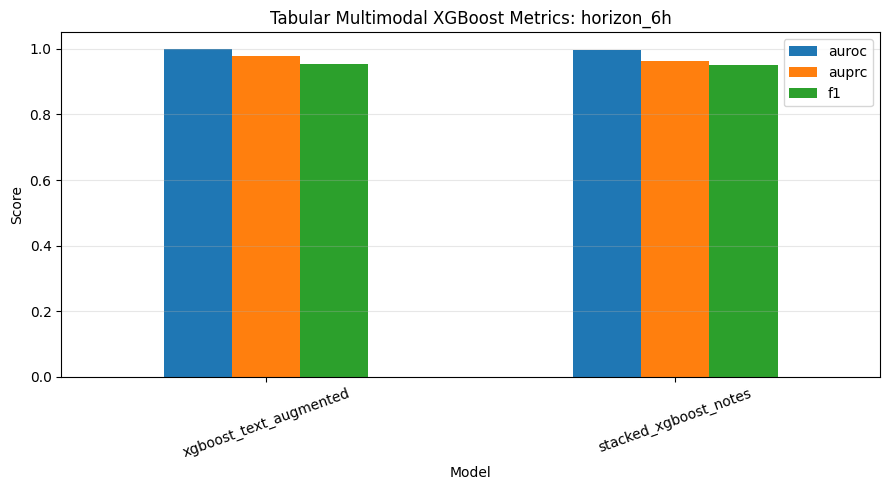

In [12]:
metric_fig, metric_ax = plot_metric_bars(
    evaluation_df=custom_eval_df,
    dataset_name=dataset_name,
    model_names=model_names,
)
metric_ax.set_title(f"{selected_family['label']} Metrics: {dataset_name}")
plt.show()


## ROC and precision-recall curves

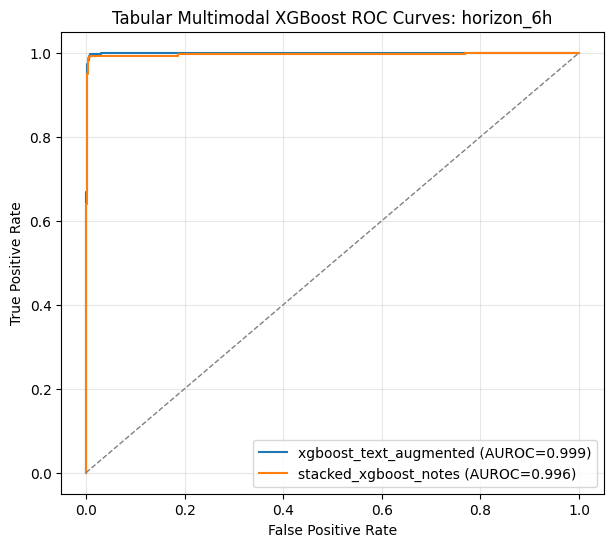

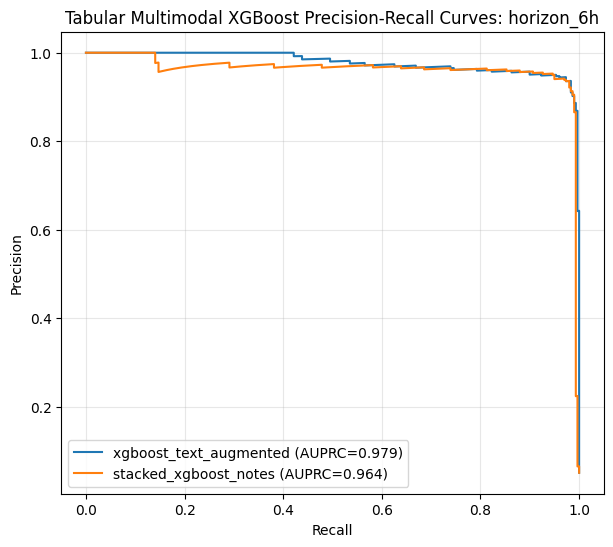

In [13]:
roc_fig, roc_ax = plt.subplots(figsize=(7, 6))
plotted_roc = False
for model_name in model_names:
    bundle = family_curve_bundle.get((dataset_name, model_name))
    if bundle is None:
        continue
    plotted_roc = True
    curve = bundle['roc_curve']
    auc = custom_eval_df.loc[
        (custom_eval_df['dataset_name'] == dataset_name) & (custom_eval_df['model_name'] == model_name),
        'auroc',
    ].iloc[0]
    roc_ax.plot(curve['fpr'], curve['tpr'], label=f'{model_name} (AUROC={auc:.3f})')
roc_ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
roc_ax.set_title(f"{selected_family['label']} ROC Curves: {dataset_name}")
roc_ax.set_xlabel('False Positive Rate')
roc_ax.set_ylabel('True Positive Rate')
roc_ax.grid(True, alpha=0.3)
if plotted_roc:
    roc_ax.legend()
plt.show()

pr_fig, pr_ax = plt.subplots(figsize=(7, 6))
plotted_pr = False
for model_name in model_names:
    bundle = family_curve_bundle.get((dataset_name, model_name))
    if bundle is None:
        continue
    plotted_pr = True
    curve = bundle['pr_curve']
    auprc = custom_eval_df.loc[
        (custom_eval_df['dataset_name'] == dataset_name) & (custom_eval_df['model_name'] == model_name),
        'auprc',
    ].iloc[0]
    pr_ax.plot(curve['recall'], curve['precision'], label=f'{model_name} (AUPRC={auprc:.3f})')
pr_ax.set_title(f"{selected_family['label']} Precision-Recall Curves: {dataset_name}")
pr_ax.set_xlabel('Recall')
pr_ax.set_ylabel('Precision')
pr_ax.grid(True, alpha=0.3)
if plotted_pr:
    pr_ax.legend()
plt.show()


## Calibration and confusion matrices

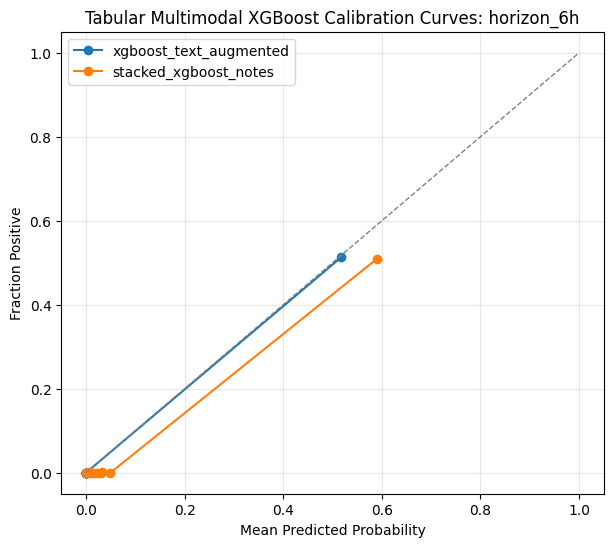

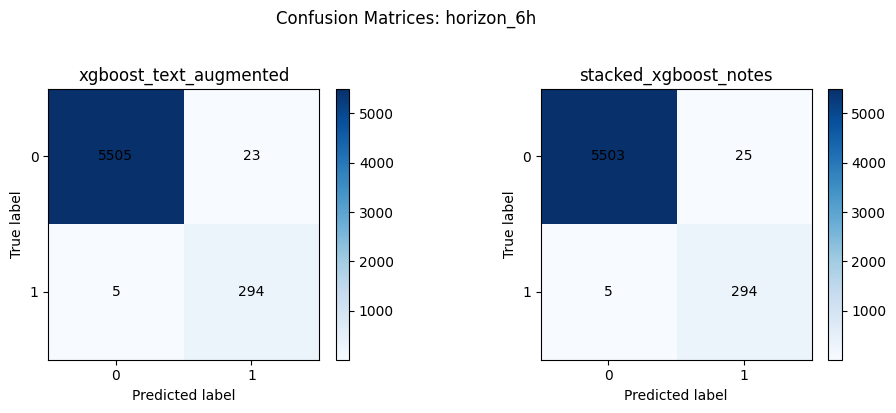

In [14]:
calibration_fig, calibration_ax = plt.subplots(figsize=(7, 6))
plotted_calibration = False
for model_name in model_names:
    bundle = family_curve_bundle.get((dataset_name, model_name))
    if bundle is None:
        continue
    plotted_calibration = True
    curve = bundle['calibration']
    calibration_ax.plot(
        curve['mean_predicted_probability'],
        curve['fraction_positive'],
        marker='o',
        label=model_name,
    )
calibration_ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
calibration_ax.set_title(f"{selected_family['label']} Calibration Curves: {dataset_name}")
calibration_ax.set_xlabel('Mean Predicted Probability')
calibration_ax.set_ylabel('Fraction Positive')
calibration_ax.grid(True, alpha=0.3)
if plotted_calibration:
    calibration_ax.legend()
plt.show()

confusion_fig, confusion_axes = plot_confusion_matrices(
    prediction_dir=prediction_dir,
    dataset_name=dataset_name,
    threshold=None,
    model_names=model_names,
)
plt.show()


## Validation vs test curve comparison

When raw split predictions are available, these figures compare validation and test behavior for `xgboost_text_augmented`. Large drops from validation to test would indicate overfitting.

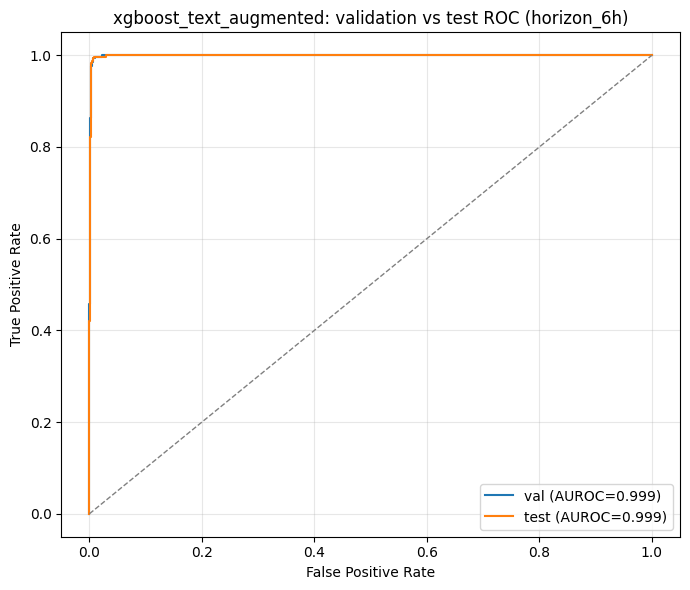

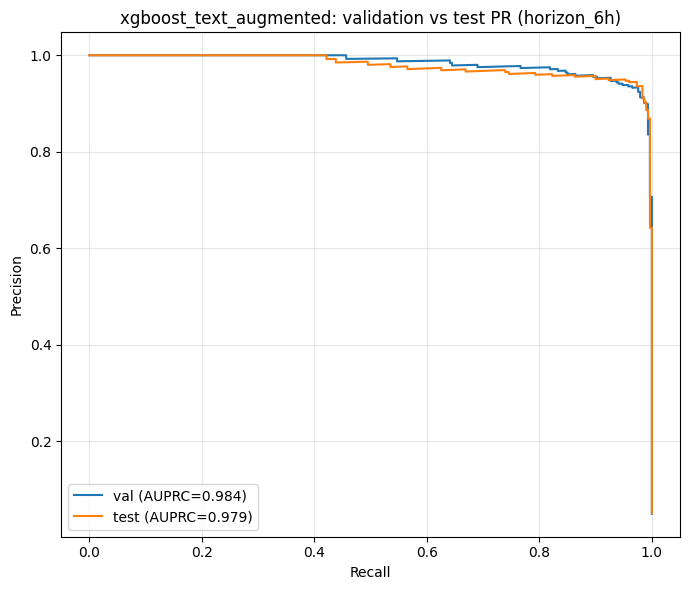

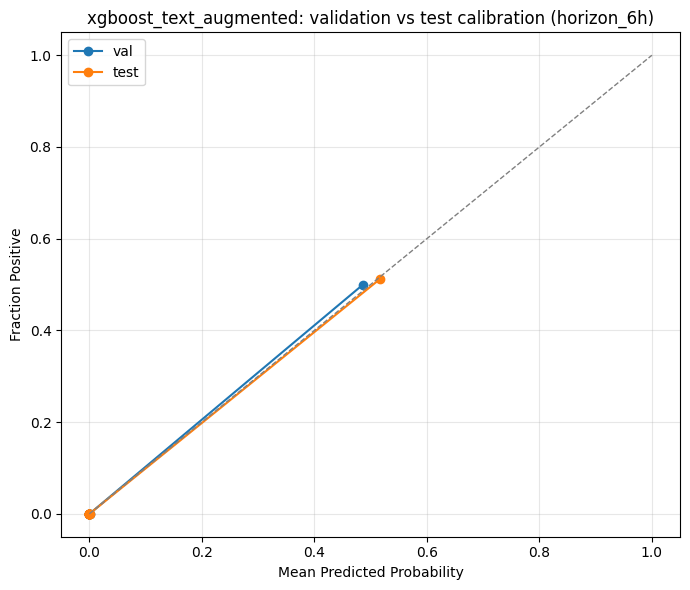

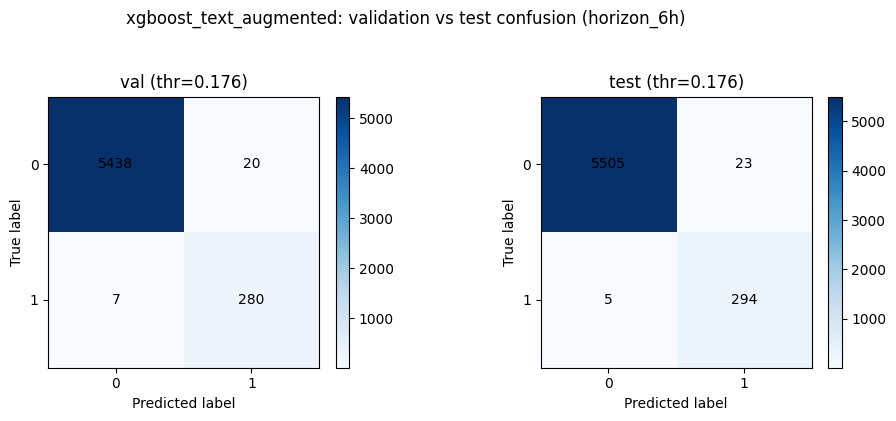

In [15]:
split_roc_fig = None
split_pr_fig = None
split_calibration_fig = None
split_confusion_fig = None

if split_curve_bundle:
    split_roc_fig, split_roc_ax = plt.subplots(figsize=(7, 6))
    for split_name, bundle in split_curve_bundle.items():
        curve = bundle['roc_curve']
        split_auc = bundle['metrics']['auroc']
        split_roc_ax.plot(curve['fpr'], curve['tpr'], label=f'{split_name} (AUROC={split_auc:.3f})')
    split_roc_ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
    split_roc_ax.set_title(f'{overfit_model_name}: validation vs test ROC ({dataset_name})')
    split_roc_ax.set_xlabel('False Positive Rate')
    split_roc_ax.set_ylabel('True Positive Rate')
    split_roc_ax.grid(True, alpha=0.3)
    split_roc_ax.legend()
    split_roc_fig.tight_layout()
    plt.show()

    split_pr_fig, split_pr_ax = plt.subplots(figsize=(7, 6))
    for split_name, bundle in split_curve_bundle.items():
        curve = bundle['pr_curve']
        split_auprc = bundle['metrics']['auprc']
        split_pr_ax.plot(curve['recall'], curve['precision'], label=f'{split_name} (AUPRC={split_auprc:.3f})')
    split_pr_ax.set_title(f'{overfit_model_name}: validation vs test PR ({dataset_name})')
    split_pr_ax.set_xlabel('Recall')
    split_pr_ax.set_ylabel('Precision')
    split_pr_ax.grid(True, alpha=0.3)
    split_pr_ax.legend()
    split_pr_fig.tight_layout()
    plt.show()

    split_calibration_fig, split_calibration_ax = plt.subplots(figsize=(7, 6))
    for split_name, bundle in split_curve_bundle.items():
        curve = bundle['calibration']
        split_calibration_ax.plot(
            curve['mean_predicted_probability'],
            curve['fraction_positive'],
            marker='o',
            label=split_name,
        )
    split_calibration_ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
    split_calibration_ax.set_title(f'{overfit_model_name}: validation vs test calibration ({dataset_name})')
    split_calibration_ax.set_xlabel('Mean Predicted Probability')
    split_calibration_ax.set_ylabel('Fraction Positive')
    split_calibration_ax.grid(True, alpha=0.3)
    split_calibration_ax.legend()
    split_calibration_fig.tight_layout()
    plt.show()

    split_names = list(split_prediction_tables.keys())
    split_confusion_fig, split_confusion_axes = plt.subplots(1, len(split_names), figsize=(5 * len(split_names), 4))
    if len(split_names) == 1:
        split_confusion_axes = [split_confusion_axes]
    for axis, split_name in zip(split_confusion_axes, split_names):
        predictions_df = split_prediction_tables[split_name]
        threshold_values = pd.to_numeric(predictions_df.get('decision_threshold', pd.Series(dtype=float)), errors='coerce').dropna()
        resolved_threshold = float(threshold_values.iloc[0]) if not threshold_values.empty else float(config['evaluation']['default_threshold'])
        y_true = predictions_df['y_true'].astype(int)
        y_pred = (predictions_df['y_prob'].astype(float) >= resolved_threshold).astype(int)
        matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
        image = axis.imshow(matrix, cmap='Blues')
        axis.set_title(f'{split_name} (thr={resolved_threshold:.3f})')
        axis.set_xlabel('Predicted label')
        axis.set_ylabel('True label')
        axis.set_xticks([0, 1])
        axis.set_yticks([0, 1])
        axis.set_xticklabels(['0', '1'])
        axis.set_yticklabels(['0', '1'])
        for row in range(matrix.shape[0]):
            for column in range(matrix.shape[1]):
                axis.text(column, row, str(matrix[row, column]), ha='center', va='center', color='black')
        split_confusion_fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    split_confusion_fig.suptitle(f'{overfit_model_name}: validation vs test confusion ({dataset_name})', y=1.04)
    split_confusion_fig.tight_layout()
    plt.show()
else:
    print('No raw validation/test prediction tables were found for split comparison.')


## Save figure files

In [16]:
dataset_figure_dir = figure_output_dir / dataset_name
dataset_figure_dir.mkdir(parents=True, exist_ok=True)

saved_paths = {
    'metric_comparison': str(dataset_figure_dir / 'metric_comparison.png'),
    'roc_curves': str(dataset_figure_dir / 'roc_curves.png'),
    'pr_curves': str(dataset_figure_dir / 'pr_curves.png'),
    'calibration_curves': str(dataset_figure_dir / 'calibration_curves.png'),
    'confusion_matrices': str(dataset_figure_dir / 'confusion_matrices.png'),
}
if combined_metric_fig is not None:
    saved_paths.update({
        'cross_family_metric_comparison': str(dataset_figure_dir / 'cross_family_metric_comparison.png'),
        'cross_family_roc_curves': str(dataset_figure_dir / 'cross_family_roc_curves.png'),
        'cross_family_pr_curves': str(dataset_figure_dir / 'cross_family_pr_curves.png'),
        'cross_family_calibration_curves': str(dataset_figure_dir / 'cross_family_calibration_curves.png'),
        'cross_family_confusion_matrices': str(dataset_figure_dir / 'cross_family_confusion_matrices.png'),
    })

if split_roc_fig is not None:
    saved_paths.update({
        'split_roc_curves': str(dataset_figure_dir / 'split_roc_curves.png'),
        'split_pr_curves': str(dataset_figure_dir / 'split_pr_curves.png'),
        'split_calibration_curves': str(dataset_figure_dir / 'split_calibration_curves.png'),
        'split_confusion_matrices': str(dataset_figure_dir / 'split_confusion_matrices.png'),
    })

metric_fig.savefig(saved_paths['metric_comparison'], dpi=160, bbox_inches='tight')
roc_fig.savefig(saved_paths['roc_curves'], dpi=160, bbox_inches='tight')
pr_fig.savefig(saved_paths['pr_curves'], dpi=160, bbox_inches='tight')
calibration_fig.savefig(saved_paths['calibration_curves'], dpi=160, bbox_inches='tight')
confusion_fig.savefig(saved_paths['confusion_matrices'], dpi=160, bbox_inches='tight')
if combined_metric_fig is not None:
    combined_metric_fig.savefig(saved_paths['cross_family_metric_comparison'], dpi=160, bbox_inches='tight')
    combined_roc_fig.savefig(saved_paths['cross_family_roc_curves'], dpi=160, bbox_inches='tight')
    combined_pr_fig.savefig(saved_paths['cross_family_pr_curves'], dpi=160, bbox_inches='tight')
    combined_calibration_fig.savefig(saved_paths['cross_family_calibration_curves'], dpi=160, bbox_inches='tight')
    combined_confusion_fig.savefig(saved_paths['cross_family_confusion_matrices'], dpi=160, bbox_inches='tight')

if split_roc_fig is not None:
    split_roc_fig.savefig(saved_paths['split_roc_curves'], dpi=160, bbox_inches='tight')
    split_pr_fig.savefig(saved_paths['split_pr_curves'], dpi=160, bbox_inches='tight')
    split_calibration_fig.savefig(saved_paths['split_calibration_curves'], dpi=160, bbox_inches='tight')
    split_confusion_fig.savefig(saved_paths['split_confusion_matrices'], dpi=160, bbox_inches='tight')

manifest_path = paths['manifests_dir'] / '11_custom_model_visualization_manifest.json'
write_run_manifest(
    path=manifest_path,
    stage='11_custom_model_visualization',
    config=config,
    extra={
        'model_family': model_family,
        'dataset_name': dataset_name,
        'model_names': model_names,
        'overfit_model_name': overfit_model_name,
        'saved_paths': saved_paths,
    },
)

saved_paths, manifest_path

({'metric_comparison': '/home/sra/shankari/Multimodal-Sepsis-Prediction-main-copy/figures/11_custom_model_visualization/horizon_6h/metric_comparison.png',
  'roc_curves': '/home/sra/shankari/Multimodal-Sepsis-Prediction-main-copy/figures/11_custom_model_visualization/horizon_6h/roc_curves.png',
  'pr_curves': '/home/sra/shankari/Multimodal-Sepsis-Prediction-main-copy/figures/11_custom_model_visualization/horizon_6h/pr_curves.png',
  'calibration_curves': '/home/sra/shankari/Multimodal-Sepsis-Prediction-main-copy/figures/11_custom_model_visualization/horizon_6h/calibration_curves.png',
  'confusion_matrices': '/home/sra/shankari/Multimodal-Sepsis-Prediction-main-copy/figures/11_custom_model_visualization/horizon_6h/confusion_matrices.png',
  'cross_family_metric_comparison': '/home/sra/shankari/Multimodal-Sepsis-Prediction-main-copy/figures/11_custom_model_visualization/horizon_6h/cross_family_metric_comparison.png',
  'cross_family_roc_curves': '/home/sra/shankari/Multimodal-Sepsis-Pre